# 📊 Analyse du Dataset Tweets - Service Client Free
## 

---

### 🎯 Objectif
Identifier et éliminer les tweets non nécessaires ou erronés pour optimiser le traitement des vraies demandes clients.

### 📚 Structure du notebook
1. **Import et configuration**
2. **Chargement et exploration des données**
3. **Analyse de la qualité des données**
4. **Identification des tweets problématiques**
5. **Nettoyage et structuration**
6. **Visualisations et insights**
7. **Export des résultats**

## 1. Import des librairies et configuration

In [33]:
# Import des librairies nécessaires
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import re
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

# Configuration de l'affichage
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 100)

# Configuration des graphiques
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("✅ Librairies importées avec succès")
print(f"📅 Date d'analyse: {datetime.now().strftime('%d/%m/%Y %H:%M')}")

✅ Librairies importées avec succès
📅 Date d'analyse: 10/11/2025 14:58


## 2. Chargement et exploration initiale des données

In [54]:
# Chargement du fichier CSV
file_path = 'C:/Users/AyoubJELLOULI/Desktop/HETIC/Projet_RNCP/git_repos/SAVAI-BACK/free_tweet_export.csv'
df = pd.read_csv(file_path)

print("📊 INFORMATIONS GÉNÉRALES DU DATASET")
print("=" * 60)
print(f"Nombre de tweets: {len(df):,}")
print(f"Nombre de colonnes: {len(df.columns)}")
print(f"\nPériode couverte:")
print(f"  • Du: {df['created_at'].min()}")
print(f"  • Au: {df['created_at'].max()}")

print("\n📋 Colonnes disponibles:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2}. {col}")

📊 INFORMATIONS GÉNÉRALES DU DATASET
Nombre de tweets: 6,375
Nombre de colonnes: 22

Période couverte:
  • Du: 2020-12-28 08:26:23 +01:00
  • Au: 2025-06-17 12:03:57 +02:00

📋 Colonnes disponibles:
   1. id
   2. created_at
   3. full_text
   4. media
   5. screen_name
   6. name
   7. profile_image_url
   8. user_id
   9. in_reply_to
  10. retweeted_status
  11. quoted_status
  12. media_tags
  13. favorite_count
  14. retweet_count
  15. bookmark_count
  16. quote_count
  17. reply_count
  18. views_count
  19. favorited
  20. retweeted
  21. bookmarked
  22. url


In [35]:
nb_doublons = df.duplicated().sum()
print(f"Nombre de doublons : {nb_doublons}")

Nombre de doublons : 0


In [59]:
doubl = df[df.duplicated()].sum()
print(doubl)

id                     0
created_at             0
full_text              0
media                  0
screen_name            0
name                   0
profile_image_url      0
user_id                0
in_reply_to          0.0
retweeted_status     0.0
quoted_status        0.0
media_tags             0
favorite_count         0
retweet_count          0
bookmark_count         0
quote_count            0
reply_count            0
views_count          0.0
favorited              0
retweeted              0
bookmarked             0
url                    0
dtype: object


📊 ANALYSE DE LA COMPLÉTUDE DES DONNÉES


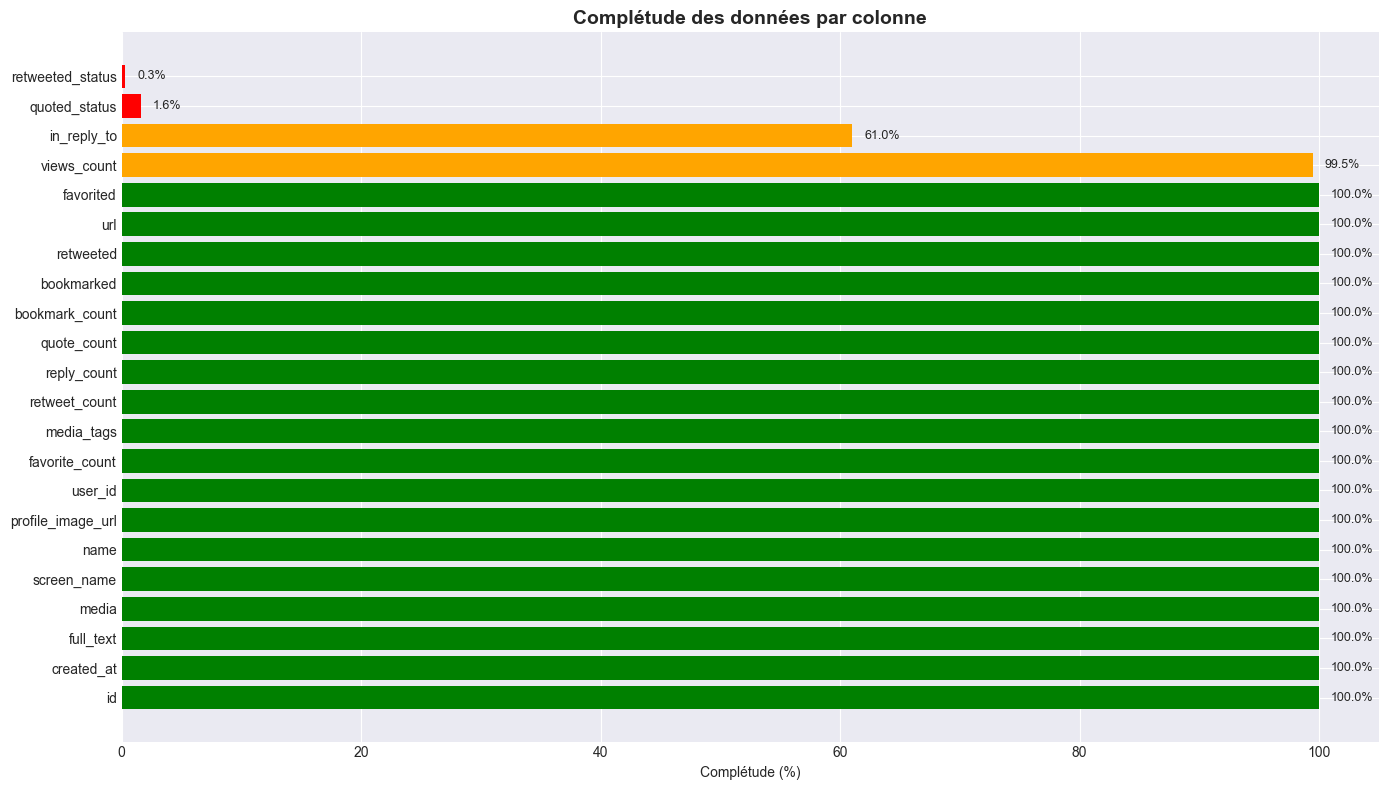

          Colonne  Valeurs_Non_Null  Valeurs_Null  Complétude_%
               id              6375             0         100.0
       created_at              6375             0         100.0
        full_text              6375             0         100.0
            media              6375             0         100.0
      screen_name              6375             0         100.0
             name              6375             0         100.0
profile_image_url              6375             0         100.0
          user_id              6375             0         100.0
   favorite_count              6375             0         100.0
       media_tags              6375             0         100.0
    retweet_count              6375             0         100.0
      reply_count              6375             0         100.0
      quote_count              6375             0         100.0
   bookmark_count              6375             0         100.0
       bookmarked              6375     

In [37]:
# Analyse de la complétude des données
print("📊 ANALYSE DE LA COMPLÉTUDE DES DONNÉES")
print("=" * 60)

completeness_data = []
for col in df.columns:
    non_null = df[col].notna().sum()
    null_count = df[col].isna().sum()
    completeness = (non_null / len(df)) * 100
    completeness_data.append({
        'Colonne': col,
        'Valeurs_Non_Null': non_null,
        'Valeurs_Null': null_count,
        'Complétude_%': round(completeness, 1)
    })

completeness_df = pd.DataFrame(completeness_data)
completeness_df = completeness_df.sort_values('Complétude_%', ascending=False)

# Visualisation de la complétude
fig, ax = plt.subplots(figsize=(14, 8))
colors = ['green' if x == 100 else 'orange' if x >= 50 else 'red' 
          for x in completeness_df['Complétude_%']]
bars = ax.barh(completeness_df['Colonne'], completeness_df['Complétude_%'], color=colors)
ax.set_xlabel('Complétude (%)')
ax.set_title('Complétude des données par colonne', fontsize=14, fontweight='bold')
ax.set_xlim(0, 105)

# Ajouter les valeurs sur les barres
for bar, value in zip(bars, completeness_df['Complétude_%']):
    ax.text(value + 1, bar.get_y() + bar.get_height()/2, 
            f'{value:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print(completeness_df.to_string(index=False))

## 3. Préparation du dataset avec les colonnes demandées

In [38]:
# Garder uniquement les colonnes demandées
colonnes_a_garder = ['id', 'created_at', 'full_text', 'screen_name', 'name', 'user_id', 'in_reply_to']

# Vérifier que toutes les colonnes existent
colonnes_manquantes = [col for col in colonnes_a_garder if col not in df.columns]
if colonnes_manquantes:
    print(f"⚠️ Colonnes manquantes: {colonnes_manquantes}")
else:
    print("✅ Toutes les colonnes demandées sont présentes")

# Créer le dataset nettoyé
df_clean = df[colonnes_a_garder].copy()

print(f"\n📋 Dataset restructuré:")
print(f"  • Nombre de colonnes conservées: {len(df_clean.columns)}")
print(f"  • Nombre de lignes: {len(df_clean):,}")
print(f"\nAperçu des premières lignes:")
df_clean.head()
df_clean.info()

✅ Toutes les colonnes demandées sont présentes

📋 Dataset restructuré:
  • Nombre de colonnes conservées: 7
  • Nombre de lignes: 6,375

Aperçu des premières lignes:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6375 entries, 0 to 6374
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           6375 non-null   int64  
 1   created_at   6375 non-null   object 
 2   full_text    6375 non-null   object 
 3   screen_name  6375 non-null   object 
 4   name         6375 non-null   object 
 5   user_id      6375 non-null   int64  
 6   in_reply_to  3887 non-null   float64
dtypes: float64(1), int64(2), object(4)
memory usage: 348.8+ KB


## 4. Fonction de catégorisation des tweets

In [ ]:
def categorize_tweet(text):
    """
    Catégorise un tweet selon son contenu.
    
    Args:
        text: Le texte du tweet
    
    Returns:
        La catégorie du tweet
    """
    if pd.isna(text):
        return "Vide"
    
    text = str(text).lower()
    
    # Patterns pour identifier les types de tweets
    patterns = {
        "RT/Partage": r'^rt @',
        "Message automatique Freebox": r'messagerie privée x n\'est plus disponible|retrouvez-moi|messenger|https://t\.co/fozuyqkg|via https://t\.co/3rzd3',
        "Plainte service": r'coupure|panne|problème|pas de connexion|ne fonctionne pas|bug|instable|service client|pire opérateur|hs',
        "Demande d'aide": r'besoin d\'aide|j\'ai besoin|aidez-moi|help|svp|s\'il vous plaît|sos',
        "Question technique": r'comment|pourquoi|qu\'est-ce|fibre|débit|wifi|connexion|installation',
        "Spam/Promotion": r'💩|via @fingapp|@outagedetect|disponible sur le canal|nouveau|offert',
        "Réclamation RDV": r'technicien|rdv|rendez-vous|pas venu|attendre|créneau',
        "Info/Annonce": r'retrouvez|nouvelle|découvrez'
    }
    
    for category, pattern in patterns.items():
        if re.search(pattern, text):
            return category
    
    return "Autre"

# Appliquer la catégorisation
df_clean['categorie'] = df_clean['full_text'].apply(categorize_tweet)

print("✅ Catégorisation effectuée")

✅ Catégorisation effectuée


## 5. Analyse des catégories de tweets

📊 RÉPARTITION DES TWEETS PAR CATÉGORIE
                  Catégorie  Nombre  Pourcentage
Message automatique Freebox    3198         50.2
                      Autre    1390         21.8
            Plainte service     765         12.0
         Question technique     677         10.6
            Réclamation RDV     123          1.9
             Demande d'aide     119          1.9
             Spam/Promotion      44          0.7
               Info/Annonce      43          0.7
                 RT/Partage      16          0.3


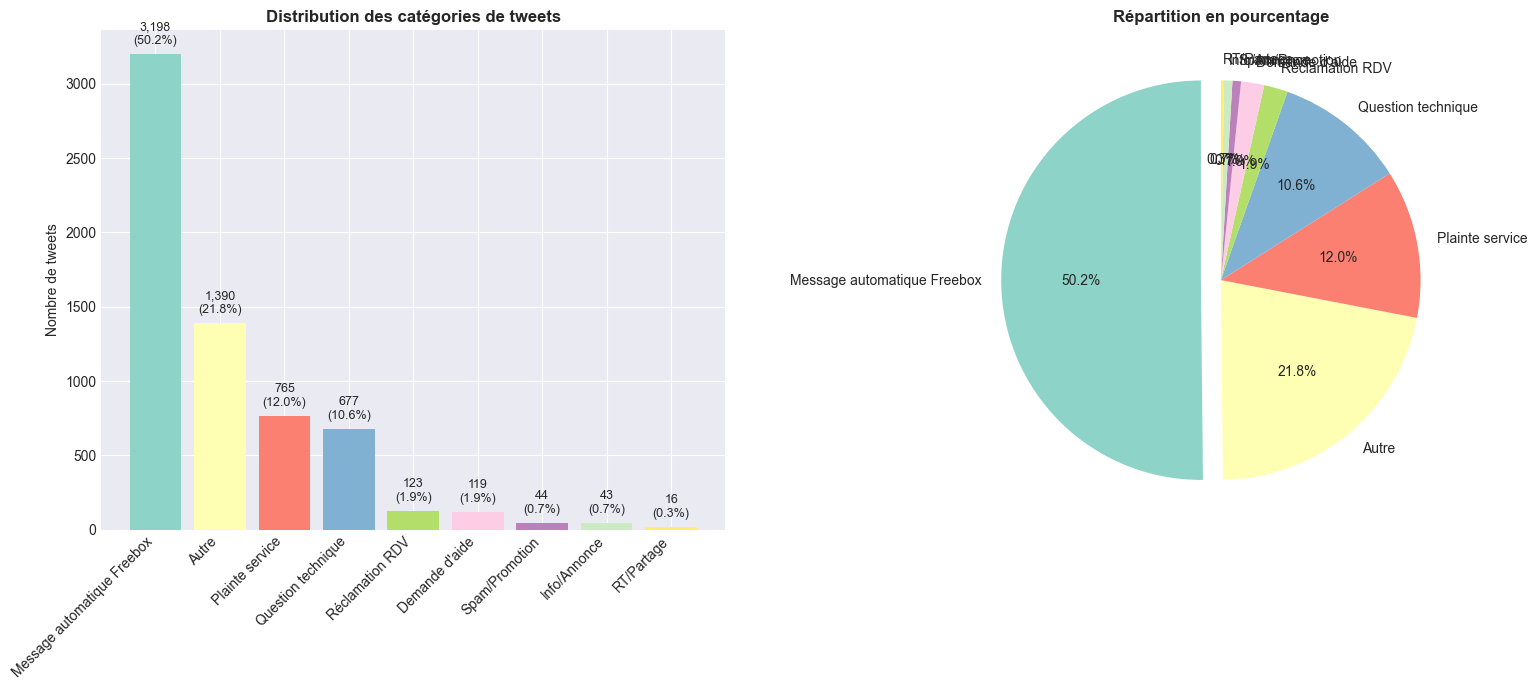

In [40]:
# Statistiques par catégorie
category_stats = df_clean['categorie'].value_counts()
category_percentages = (category_stats / len(df_clean) * 100).round(1)

# Créer un DataFrame pour l'affichage
stats_df = pd.DataFrame({
    'Catégorie': category_stats.index,
    'Nombre': category_stats.values,
    'Pourcentage': category_percentages.values
})

print("📊 RÉPARTITION DES TWEETS PAR CATÉGORIE")
print("=" * 60)
print(stats_df.to_string(index=False))

# Visualisation
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Graphique en barres
colors = plt.cm.Set3(np.linspace(0, 1, len(category_stats)))
bars = ax1.bar(range(len(category_stats)), category_stats.values, color=colors)
ax1.set_xticks(range(len(category_stats)))
ax1.set_xticklabels(category_stats.index, rotation=45, ha='right')
ax1.set_ylabel('Nombre de tweets')
ax1.set_title('Distribution des catégories de tweets', fontweight='bold')

# Ajouter les valeurs sur les barres
for bar, value in zip(bars, category_stats.values):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 50,
            f'{value:,}\n({value/len(df_clean)*100:.1f}%)',
            ha='center', va='bottom', fontsize=9)

# Graphique camembert
explode = [0.1 if cat == 'Message automatique Freebox' else 0 for cat in category_stats.index]
ax2.pie(category_stats.values, labels=category_stats.index, autopct='%1.1f%%',
        colors=colors, explode=explode, startangle=90)
ax2.set_title('Répartition en pourcentage', fontweight='bold')

plt.tight_layout()
plt.show()

## 6. Identification des tweets problématiques

In [66]:
def is_unnecessary_or_erroneous(row):
    """
    Identifie si un tweet est non nécessaire ou erroné.
    
    Args:
        row: Une ligne du DataFrame
    
    Returns:
        tuple: (bool, list) - (est problématique, liste des problèmes)
    """
    issues = []
    
    if pd.isna(row['full_text']):
        issues.append("Texte vide")
        return True, issues
    
    text = str(row['full_text']).lower()
    
    # Critères pour tweets non nécessaires
    if row['categorie'] == 'Message automatique Freebox':
        issues.append("Réponse automatique répétitive")
    
    if row['categorie'] == 'RT/Partage':
        issues.append("Retweet (pas une demande directe)")
    
    if row['categorie'] == 'Spam/Promotion':
        issues.append("Spam ou promotion non pertinente")
    
    # Tweets trop courts pour être utiles
    if len(str(row['full_text'])) < 20:
        issues.append("Tweet trop court (<20 caractères)")
    
    # Messages dupliqués (même contenu)
    if 'la messagerie privée x n\'est plus disponible' in text and row['screen_name'] == 'Freebox':
        issues.append("Message standard répétitif de Freebox")
    
    # Tweets sans contexte
    if row['in_reply_to'] == 'null' and len(text) < 50 and '?' not in text and row['screen_name'] != 'Freebox':
        issues.append("Message court sans contexte ni question")
    
    return len(issues) > 0, issues

# Analyse des tweets problématiques
print("🔍 Analyse des tweets problématiques en cours...")

problematic_tweets = []
for idx, row in df_clean.iterrows():
    is_problematic, issues = is_unnecessary_or_erroneous(row)
    if is_problematic:
        problematic_tweets.append({
            'index': idx,
            'id': row['id'],
            'screen_name': row['screen_name'],
            'categorie': row['categorie'],
            'issues': ', '.join(issues),
            'extrait': str(row['full_text'])[:100] + '...' if len(str(row['full_text'])) > 100 else str(row['full_text'])
        })

df_problematic = pd.DataFrame(problematic_tweets)

print(f"\n⚠️ RÉSULTATS DE L'ANALYSE")
print("=" * 60)
print(f"Tweets problématiques identifiés: {len(df_problematic):,} sur {len(df_clean):,}")
print(f"Pourcentage de tweets problématiques: {len(df_problematic)*100/len(df_clean):.1f}%")
print(f"Tweets pertinents conservés: {len(df_clean) - len(df_problematic):,}")
print(f"Pourcentage de tweets pertinents: {(len(df_clean) - len(df_problematic))*100/len(df_clean):.1f}%\n")

🔍 Analyse des tweets problématiques en cours...

⚠️ RÉSULTATS DE L'ANALYSE
Tweets problématiques identifiés: 3,268 sur 6,375
Pourcentage de tweets problématiques: 51.3%
Tweets pertinents conservés: 3,107
Pourcentage de tweets pertinents: 48.7%




📊 TOP DES PROBLÈMES IDENTIFIÉS
                         Problème  Occurrences  Pourcentage
   Réponse automatique répétitive         3198         97.9
 Spam ou promotion non pertinente           44          1.3
Retweet (pas une demande directe)           16          0.5
Tweet trop court (<20 caractères)           10          0.3


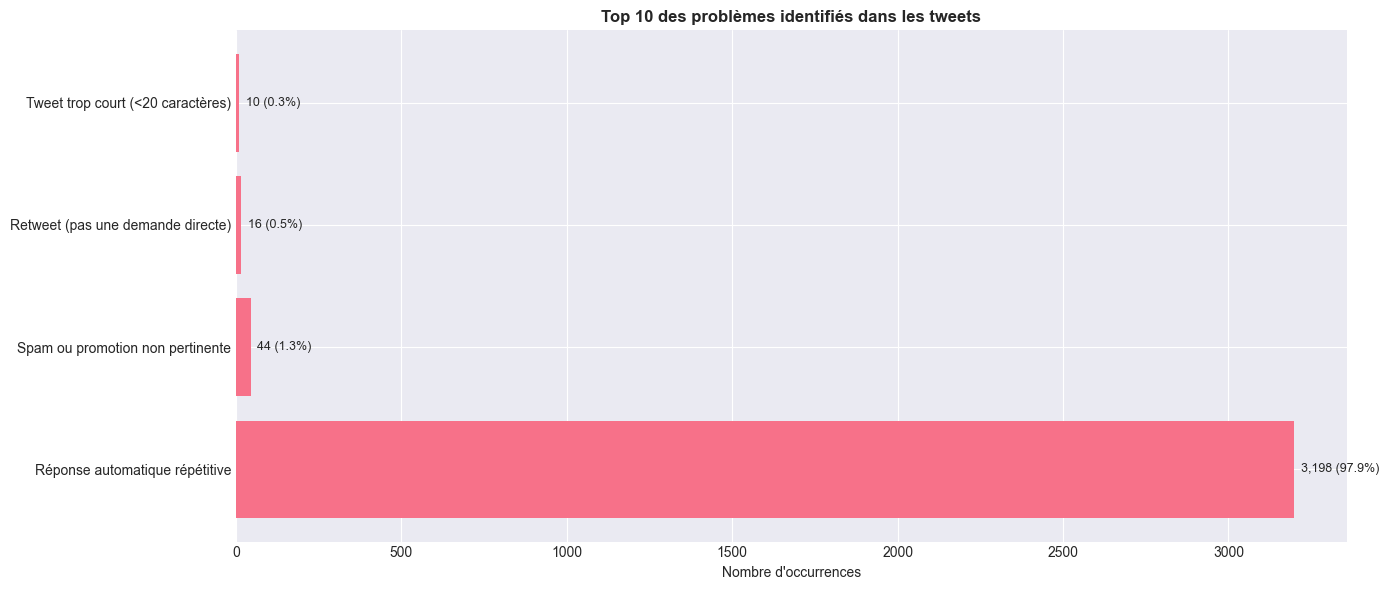

In [42]:
# Analyse des types de problèmes
if len(df_problematic) > 0:
    issues_split = df_problematic['issues'].str.split(', ', expand=True).stack()
    issue_counts = issues_split.value_counts()
    
    print("\n📊 TOP DES PROBLÈMES IDENTIFIÉS")
    print("=" * 60)
    
    issue_stats = pd.DataFrame({
        'Problème': issue_counts.index[:10],
        'Occurrences': issue_counts.values[:10],
        'Pourcentage': (issue_counts.values[:10] / len(df_problematic) * 100).round(1)
    })
    
    print(issue_stats.to_string(index=False))
    
    # Visualisation
    plt.figure(figsize=(14, 6))
    bars = plt.barh(range(len(issue_counts.head(10))), issue_counts.head(10).values)
    plt.yticks(range(len(issue_counts.head(10))), issue_counts.head(10).index)
    plt.xlabel('Nombre d\'occurrences')
    plt.title('Top 10 des problèmes identifiés dans les tweets', fontweight='bold')
    
    # Ajouter les valeurs sur les barres
    for i, (bar, value) in enumerate(zip(bars, issue_counts.head(10).values)):
        plt.text(value + 20, bar.get_y() + bar.get_height()/2, 
                f'{value:,} ({value/len(df_problematic)*100:.1f}%)',
                va='center', fontsize=9)
    
    plt.tight_layout()
    plt.show()

## 7. Analyse des comptes les plus actifs

👥 TOP 15 DES COMPTES LES PLUS ACTIFS
   screen_name  nombre_tweets        categorie_principale  pourcentage
       Freebox           3242 Message automatique Freebox        50.85
          free             58                       Autre         0.91
     Free_1337             18                       Autre         0.28
zoneadsl_panne             11             Plainte service         0.17
UniversFreebox              9                       Autre         0.14
       t_5502m              7                       Autre         0.11
      Xavier75              6                       Autre         0.09
  BusyspiderFr              5          Question technique         0.08
      TiinoX83              5                       Autre         0.08
    Juliendu75              4                       Autre         0.06
     GrumoBlog              4             Plainte service         0.06
   Fredo384450              4                       Autre         0.06
   GroupeIliad              4           

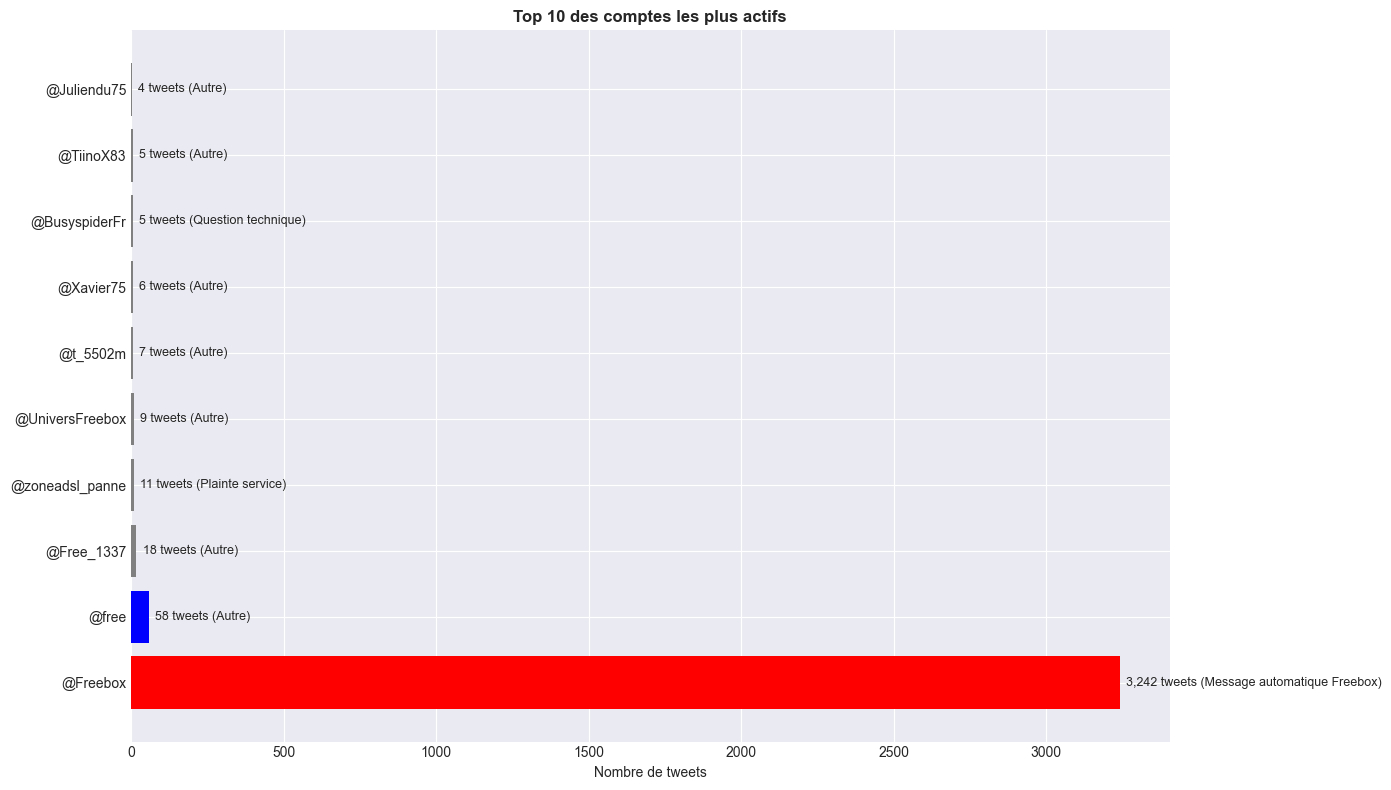

In [43]:
# Analyse des comptes
user_stats = df_clean.groupby('screen_name').agg({
    'id': 'count',
    'categorie': lambda x: x.mode()[0] if len(x) > 0 else 'N/A'
}).sort_values('id', ascending=False).head(15)
user_stats.columns = ['nombre_tweets', 'categorie_principale']

print("👥 TOP 15 DES COMPTES LES PLUS ACTIFS")
print("=" * 60)

user_display = user_stats.reset_index()
user_display['pourcentage'] = (user_display['nombre_tweets'] / len(df_clean) * 100).round(2)
print(user_display.to_string(index=False))

# Visualisation
fig, ax = plt.subplots(figsize=(14, 8))
colors = ['red' if user == 'Freebox' else 'blue' if user == 'free' else 'gray' 
          for user in user_stats.index[:10]]
bars = ax.barh(range(10), user_stats['nombre_tweets'].values[:10], color=colors)
ax.set_yticks(range(10))
ax.set_yticklabels([f'@{user}' for user in user_stats.index[:10]])
ax.set_xlabel('Nombre de tweets')
ax.set_title('Top 10 des comptes les plus actifs', fontweight='bold')

# Ajouter les valeurs et catégories
for i, (bar, value, cat) in enumerate(zip(bars, 
                                          user_stats['nombre_tweets'].values[:10],
                                          user_stats['categorie_principale'].values[:10])):
    ax.text(value + 20, bar.get_y() + bar.get_height()/2,
           f'{value:,} tweets ({cat})',
           va='center', fontsize=9)

plt.tight_layout()
plt.show()

## 8. Exemples de tweets problématiques

In [44]:
# Afficher des exemples de tweets problématiques
print("📝 EXEMPLES DE TWEETS PROBLÉMATIQUES")
print("=" * 80)

# Grouper par type de problème et afficher des exemples
if len(df_problematic) > 0:
    # Obtenir les types de problèmes uniques
    unique_issues = df_problematic['issues'].unique()[:5]
    
    for issue_type in unique_issues:
        print(f"\n🔸 Problème: {issue_type}")
        print("-" * 60)
        
        # Filtrer les tweets avec ce problème
        examples = df_problematic[df_problematic['issues'] == issue_type].head(5)
        
        for idx, row in examples.iterrows():
            print(f"  • @{row['screen_name']}: \"{row['extrait']}\"")
            print(f"    Catégorie: {row['categorie']}")
            print()

📝 EXEMPLES DE TWEETS PROBLÉMATIQUES

🔸 Problème: Retweet (pas une demande directe)
------------------------------------------------------------
  • @Freebox: "RT @free: Retrouvez désormais @ToonamiFR, la chaîne pour tous les fans de super-héros sur le canal 8..."
    Catégorie: RT/Partage

  • @Freebox: "RT @free: A suivre ce soir, le 1er match de l’UEFA EURO 2020™ en #4K sur votre Freebox avec TF1 4K !..."
    Catégorie: RT/Partage

  • @Freebox: "RT @free: Disponible sur le canal 101 avec les Freebox compatibles, Pop, Delta Devialet &amp; Mini4k..."
    Catégorie: RT/Partage

  • @Freebox: "RT @free: ⚠️ Des personnes malveillantes se font passer pour le service client de Free dans le but d..."
    Catégorie: RT/Partage

  • @Freebox: "RT @free: [NOUVEAU]\nAbonnés Freebox Pop, pour bien commencer la rentrée, CANAL+SÉRIES vous est offe..."
    Catégorie: RT/Partage


🔸 Problème: Spam ou promotion non pertinente
------------------------------------------------------------
  • @Freebox: 

## 9. Création du dataset final nettoyé

In [45]:
# Filtrer les tweets non nécessaires
df_final = df_clean[~df_clean.index.isin(df_problematic['index'])]

print("✅ NETTOYAGE FINAL EFFECTUÉ")
print("=" * 60)
print(f"Tweets conservés: {len(df_final):,} sur {len(df_clean):,} ({len(df_final)*100/len(df_clean):.1f}%)")
print(f"Tweets supprimés: {len(df_clean) - len(df_final):,} ({(len(df_clean) - len(df_final))*100/len(df_clean):.1f}%)")

# Statistiques du dataset nettoyé
final_category_stats = df_final['categorie'].value_counts()

print("\n📊 RÉPARTITION APRÈS NETTOYAGE")
print("-" * 40)
for cat, count in final_category_stats.items():
    print(f"{cat:30} {count:5} tweets ({count*100/len(df_final):5.1f}%)")

✅ NETTOYAGE FINAL EFFECTUÉ
Tweets conservés: 3,107 sur 6,375 (48.7%)
Tweets supprimés: 3,268 (51.3%)

📊 RÉPARTITION APRÈS NETTOYAGE
----------------------------------------
Autre                           1380 tweets ( 44.4%)
Plainte service                  765 tweets ( 24.6%)
Question technique               677 tweets ( 21.8%)
Réclamation RDV                  123 tweets (  4.0%)
Demande d'aide                   119 tweets (  3.8%)
Info/Annonce                      43 tweets (  1.4%)


## 10. Analyse temporelle des tweets

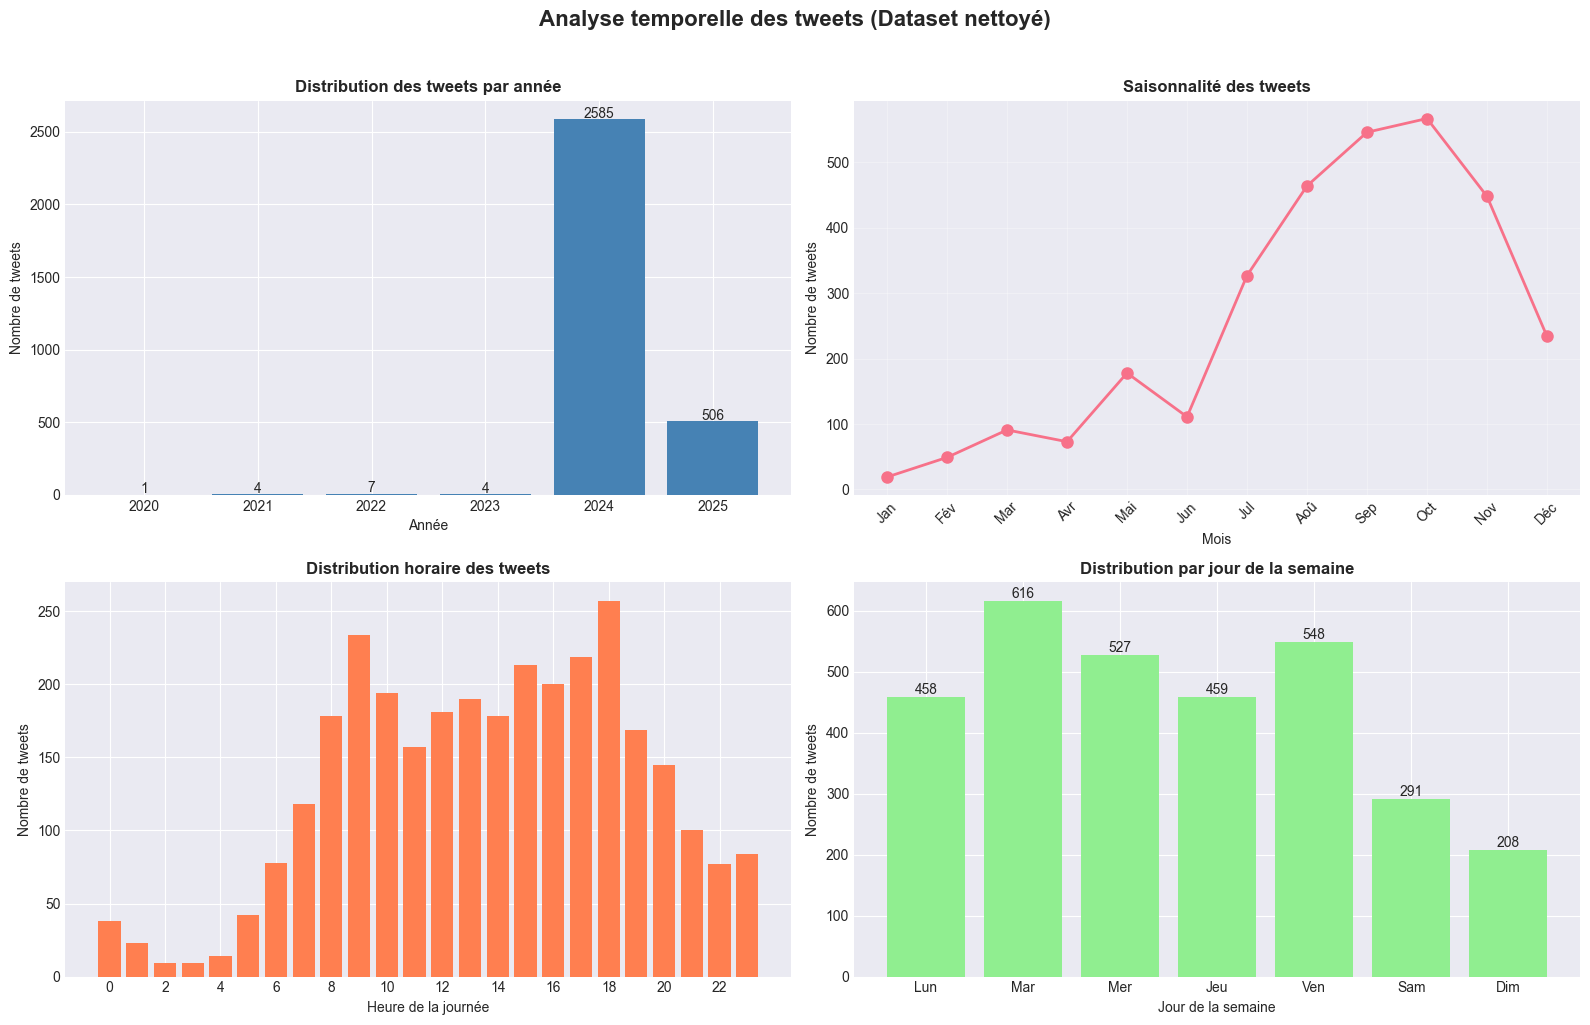

In [46]:
# Convertir les dates
df_final['created_at'] = pd.to_datetime(df_final['created_at'], utc=True)
df_final['year'] = df_final['created_at'].dt.year
df_final['month'] = df_final['created_at'].dt.month
df_final['hour'] = df_final['created_at'].dt.hour
df_final['day_of_week'] = df_final['created_at'].dt.dayofweek

# Analyse par année
yearly_stats = df_final.groupby('year').size()

# Visualisation temporelle
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Tweets par année
axes[0, 0].bar(yearly_stats.index, yearly_stats.values, color='steelblue')
axes[0, 0].set_xlabel('Année')
axes[0, 0].set_ylabel('Nombre de tweets')
axes[0, 0].set_title('Distribution des tweets par année', fontweight='bold')
for i, v in enumerate(yearly_stats.values):
    axes[0, 0].text(yearly_stats.index[i], v + 10, str(v), ha='center')

# Tweets par mois
monthly_stats = df_final.groupby('month').size()
months = ['Jan', 'Fév', 'Mar', 'Avr', 'Mai', 'Jun', 'Jul', 'Aoû', 'Sep', 'Oct', 'Nov', 'Déc']
axes[0, 1].plot(monthly_stats.index, monthly_stats.values, marker='o', linewidth=2, markersize=8)
axes[0, 1].set_xlabel('Mois')
axes[0, 1].set_ylabel('Nombre de tweets')
axes[0, 1].set_title('Saisonnalité des tweets', fontweight='bold')
axes[0, 1].set_xticks(range(1, 13))
axes[0, 1].set_xticklabels(months, rotation=45)
axes[0, 1].grid(True, alpha=0.3)

# Tweets par heure de la journée
hourly_stats = df_final.groupby('hour').size()
axes[1, 0].bar(hourly_stats.index, hourly_stats.values, color='coral')
axes[1, 0].set_xlabel('Heure de la journée')
axes[1, 0].set_ylabel('Nombre de tweets')
axes[1, 0].set_title('Distribution horaire des tweets', fontweight='bold')
axes[1, 0].set_xticks(range(0, 24, 2))

# Tweets par jour de la semaine
daily_stats = df_final.groupby('day_of_week').size()
days = ['Lun', 'Mar', 'Mer', 'Jeu', 'Ven', 'Sam', 'Dim']
axes[1, 1].bar(range(7), daily_stats.values, color='lightgreen')
axes[1, 1].set_xlabel('Jour de la semaine')
axes[1, 1].set_ylabel('Nombre de tweets')
axes[1, 1].set_title('Distribution par jour de la semaine', fontweight='bold')
axes[1, 1].set_xticks(range(7))
axes[1, 1].set_xticklabels(days)
for i, v in enumerate(daily_stats.values):
    axes[1, 1].text(i, v + 5, str(v), ha='center')

plt.suptitle('Analyse temporelle des tweets (Dataset nettoyé)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 11. Word Cloud des tweets pertinents

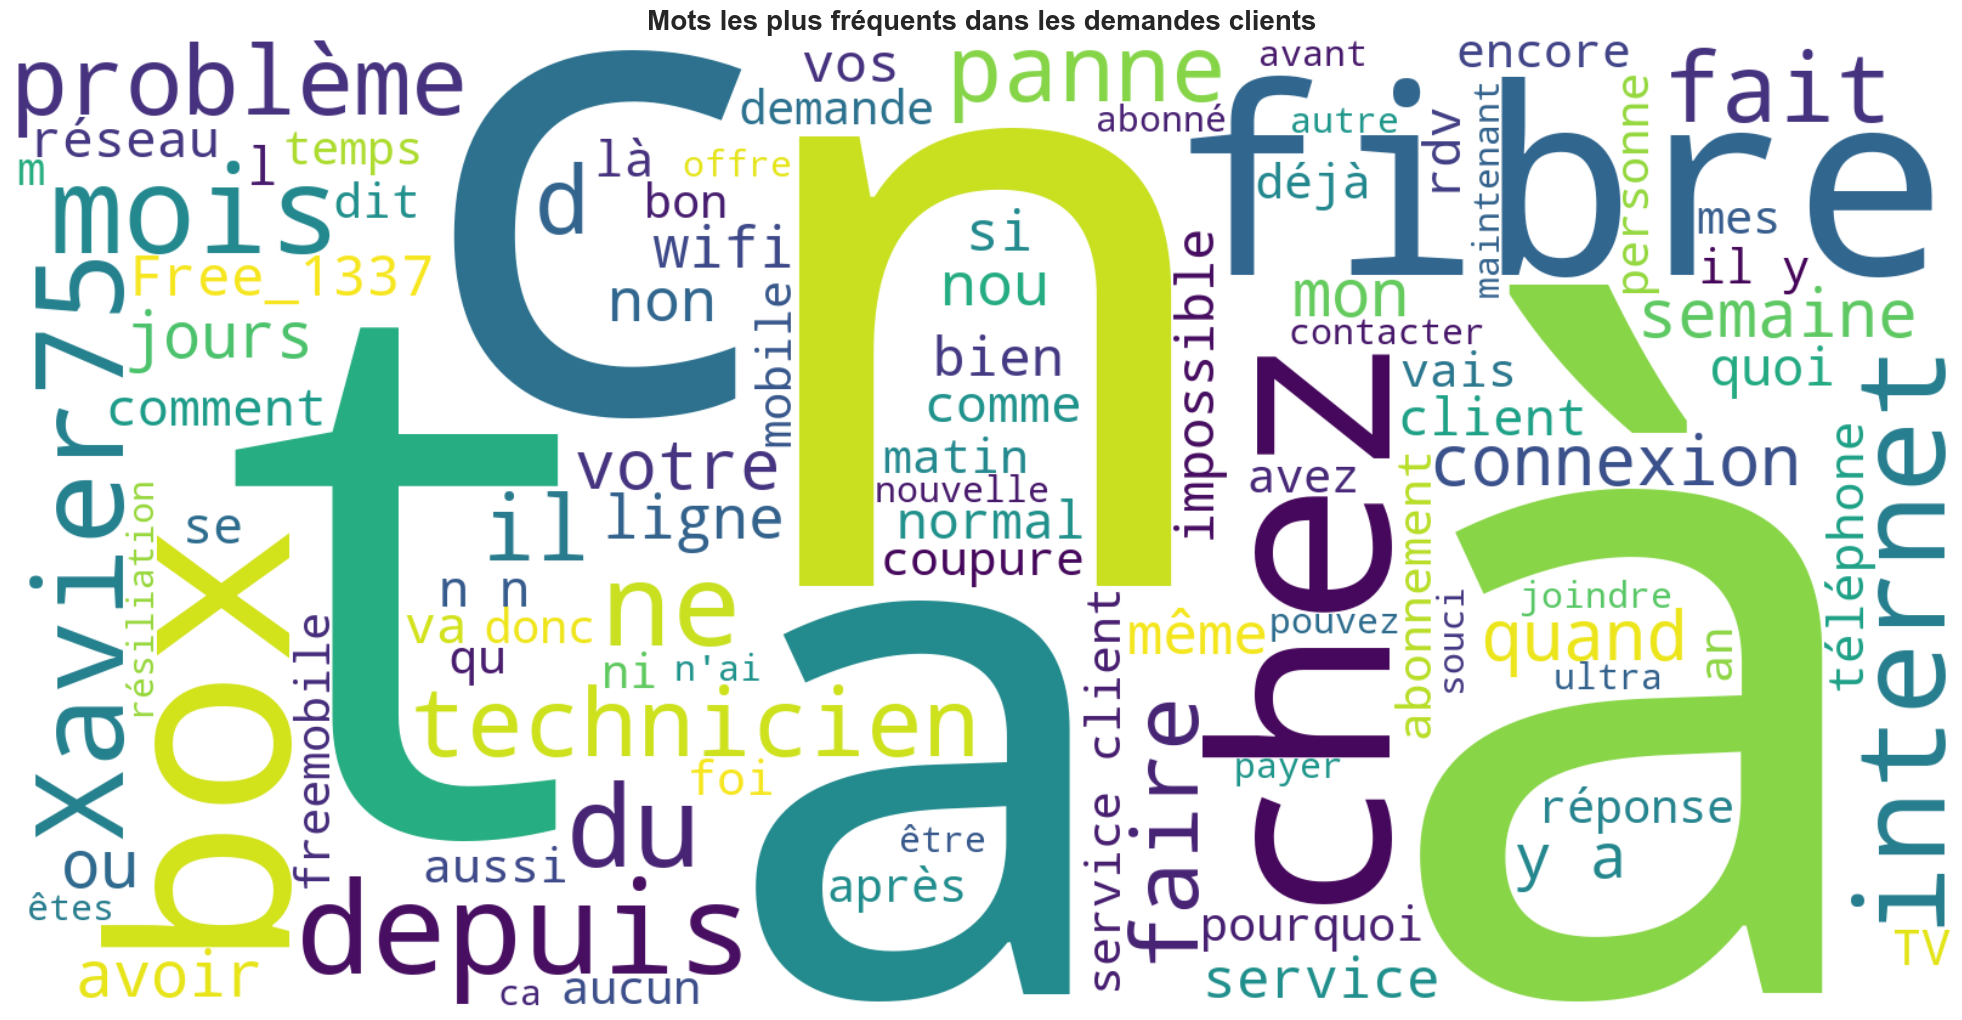

In [64]:
# Créer un word cloud des tweets pertinents (non-Freebox)
user_tweets = df_final[df_final['screen_name'] != 'Freebox']['full_text']
all_text = ' '.join(user_tweets.dropna().astype(str))

# Mots à exclure
stopwords = {'free', 'freebox', 'https', 'co', 'rt', 'de', 'la', 'le', 'et', 'un', 'une', 
             'les', 'des', 'pour', 'pas', 'sur', 'est', 'que', 'qui', 'dans', 'avec', 'par',
             'en', 'vous', 'bonjour', "c\'est", 'mais', 'plus', 'ma', 'au', 'cette', 'ce', 'chez'
             'mon', 'me', 'toujours', 'je', 'merci', 'suis', 'car', 'rien', 'svp', 'meme', 'jour',
             'moi', 'j\'ai', 'sans', 'sont', 'ça', 'tout', 'tous', 'toute', 'toutes', 'on', 'alors','j', 'ai'
            }

# Générer le word cloud
wordcloud = WordCloud(width=1600, height=800, 
                      background_color='white',
                      stopwords=stopwords,
                      max_words=100,
                      colormap='viridis').generate(all_text)

# Afficher
plt.figure(figsize=(20, 10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Mots les plus fréquents dans les demandes clients', fontsize=20, fontweight='bold')
plt.tight_layout(pad=0)
plt.show()

## 12. Recommandations et règles de filtrage

In [48]:
# Définir les règles de filtrage
filtrage_rules = [
    {
        "Priorité": "🔴 CRITIQUE",
        "Filtre": "Messages automatiques Freebox",
        "Regex": r"messagerie privée X n'est plus disponible|retrouvez-moi.*Messenger",
        "Impact": "~50% du volume",
        "Code": "df[~df['full_text'].str.contains('messagerie privée X', case=False, na=False)]"
    },
    {
        "Priorité": "🟠 HAUTE",
        "Filtre": "Retweets",
        "Regex": r"^RT @",
        "Impact": "Contenus non originaux",
        "Code": "df[~df['full_text'].str.startswith('RT @', na=False)]"
    },
    {
        "Priorité": "🟡 MOYENNE",
        "Filtre": "Messages trop courts",
        "Condition": "len(text) < 30",
        "Impact": "Messages non substantiels",
        "Code": "df[df['full_text'].str.len() >= 30]"
    },
    {
        "Priorité": "🟢 BASSE",
        "Filtre": "Spam/Promotion",
        "Liste noire": ["💩", "@fingapp", "@outagedetect"],
        "Impact": "Amélioration qualité",
        "Code": "df[~df['full_text'].str.contains('💩|@fingapp|@outagedetect', na=False)]"
    }
]

print("🛠️ RÈGLES DE FILTRAGE RECOMMANDÉES")
print("=" * 80)
print()

for rule in filtrage_rules:
    print(f"{rule['Priorité']} {rule['Filtre']}")
    print(f"   Impact attendu: Suppression de {rule['Impact']}")
    if 'Regex' in rule:
        print(f"   Pattern regex: {rule['Regex']}")
    elif 'Condition' in rule:
        print(f"   Condition: {rule['Condition']}")
    elif 'Liste noire' in rule:
        print(f"   Mots-clés à filtrer: {', '.join(rule['Liste noire'])}")
    print(f"   Code Python: {rule['Code']}")
    print()

# Fonction de filtrage complète
print("\n" + "=" * 80)
print("📝 FONCTION DE FILTRAGE COMPLÈTE")
print("=" * 80)
print()
print("""def clean_tweet_dataset(df):
    \"\"\"
    Nettoie le dataset de tweets en supprimant les tweets non pertinents.
    \"\"\"
    # Copie du DataFrame
    df_clean = df.copy()
    
    # Filtre 1: Supprimer les messages automatiques
    df_clean = df_clean[~df_clean['full_text'].str.contains(
        'messagerie privée X n\'est plus disponible', case=False, na=False)]
    
    # Filtre 2: Supprimer les retweets
    df_clean = df_clean[~df_clean['full_text'].str.startswith('RT @', na=False)]
    
    # Filtre 3: Supprimer les messages trop courts
    df_clean = df_clean[df_clean['full_text'].str.len() >= 30]
    
    # Filtre 4: Supprimer le spam
    spam_patterns = '💩|@fingapp|@outagedetect|via @fingapp'
    df_clean = df_clean[~df_clean['full_text'].str.contains(spam_patterns, na=False)]
    
    return df_clean
""")

🛠️ RÈGLES DE FILTRAGE RECOMMANDÉES

🔴 CRITIQUE Messages automatiques Freebox
   Impact attendu: Suppression de ~50% du volume
   Pattern regex: messagerie privée X n'est plus disponible|retrouvez-moi.*Messenger
   Code Python: df[~df['full_text'].str.contains('messagerie privée X', case=False, na=False)]

🟠 HAUTE Retweets
   Impact attendu: Suppression de Contenus non originaux
   Pattern regex: ^RT @
   Code Python: df[~df['full_text'].str.startswith('RT @', na=False)]

🟡 MOYENNE Messages trop courts
   Impact attendu: Suppression de Messages non substantiels
   Condition: len(text) < 30
   Code Python: df[df['full_text'].str.len() >= 30]

🟢 BASSE Spam/Promotion
   Impact attendu: Suppression de Amélioration qualité
   Mots-clés à filtrer: 💩, @fingapp, @outagedetect
   Code Python: df[~df['full_text'].str.contains('💩|@fingapp|@outagedetect', na=False)]


📝 FONCTION DE FILTRAGE COMPLÈTE

def clean_tweet_dataset(df):
    """
    Nettoie le dataset de tweets en supprimant les tweets non 

## 13. Métriques de performance et ROI

📈 MÉTRIQUES DE PERFORMANCE
Volume initial                 6375
Volume après nettoyage         3107
Tweets supprimés               3268
Taux de réduction              51.3%
Temps de traitement économisé  1634 minutes
Efficacité du filtrage         51.3%


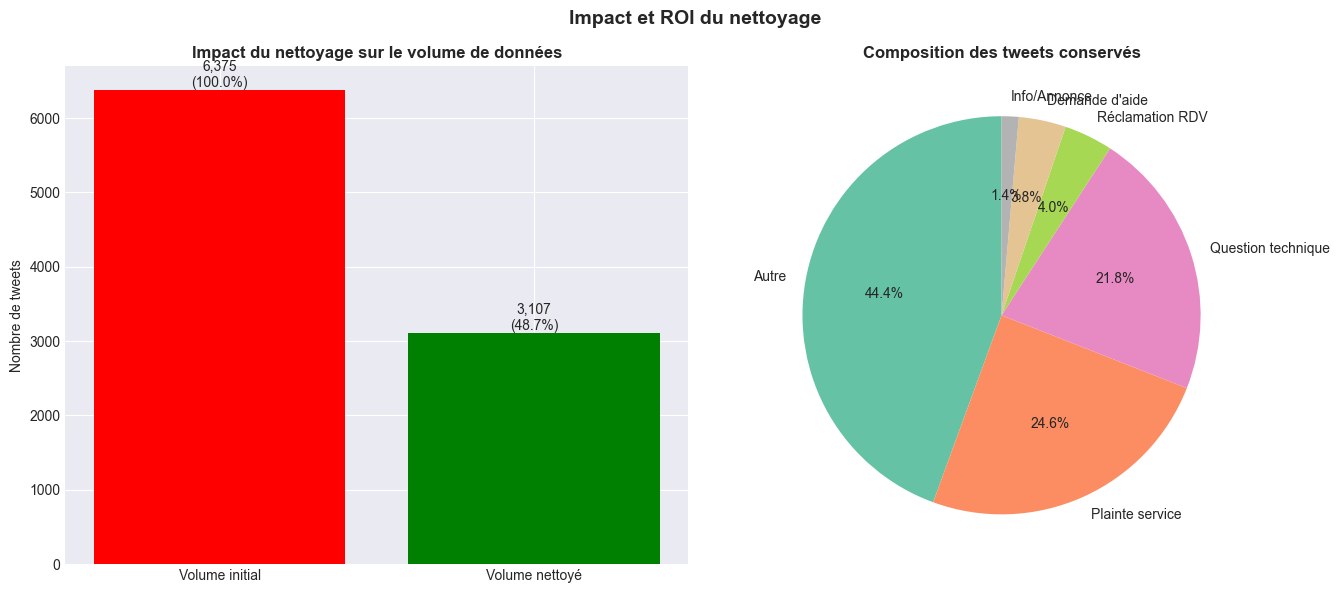

In [65]:
# Calculer les métriques de performance
metrics = {
    'Volume initial': len(df),
    'Volume après nettoyage': len(df_final),
    'Tweets supprimés': len(df) - len(df_final),
    'Taux de réduction': f"{(1 - len(df_final)/len(df))*100:.1f}%",
    'Temps de traitement économisé': f"{(len(df) - len(df_final))*0.5:.0f} minutes",  # Estimation: 30s par tweet
    'Efficacité du filtrage': f"{len(df_problematic)/len(df)*100:.1f}%"
}

print("📈 MÉTRIQUES DE PERFORMANCE")
print("=" * 60)
for key, value in metrics.items():
    print(f"{key:30} {value}")

# Visualisation du ROI
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Comparaison avant/après
categories = ['Volume initial', 'Volume nettoyé']
values = [len(df), len(df_final)]
bars = ax1.bar(categories, values, color=['red', 'green'])
ax1.set_ylabel('Nombre de tweets')
ax1.set_title('Impact du nettoyage sur le volume de données', fontweight='bold')

# Ajouter les valeurs
for bar, value in zip(bars, values):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{value:,}\n({value/len(df)*100:.1f}%)',
            ha='center', va='bottom')

# Répartition des tweets conservés
conserves_stats = df_final['categorie'].value_counts()
colors_conserves = plt.cm.Set2(np.linspace(0, 1, len(conserves_stats)))
ax2.pie(conserves_stats.values, labels=conserves_stats.index, autopct='%1.1f%%',
        colors=colors_conserves, startangle=90)
ax2.set_title('Composition des tweets conservés', fontweight='bold')

plt.suptitle('Impact et ROI du nettoyage', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 14. Export des résultats

In [50]:
# Sauvegarder les résultats
output_dir = 'C:/Users/AyoubJELLOULI/Desktop/HETIC/Projet_RNCP/git_repos/SAVAI-BACK/data/output/'  

# Créer le dossier s'il n'existe pas
import os
os.makedirs(output_dir, exist_ok=True)

# 1. Dataset nettoyé
df_final.to_csv(f'{output_dir}tweets_free_cleaned.csv', index=False)
print(f"✅ Dataset nettoyé sauvegardé: {output_dir}tweets_free_cleaned.csv")

# 2. Liste des tweets problématiques
df_problematic.to_csv(f'{output_dir}tweets_problematiques.csv', index=False)
print(f"✅ Tweets problématiques sauvegardés: {output_dir}tweets_problematiques.csv")

# 3. Statistiques générales
with open(f'{output_dir}statistiques_analyse.txt', 'w', encoding='utf-8') as f:
    f.write("STATISTIQUES D'ANALYSE DES TWEETS FREE\n")
    f.write("=" * 60 + "\n\n")
    f.write(f"Date d'analyse: {datetime.now().strftime('%d/%m/%Y %H:%M')}\n")
    f.write(f"Volume initial: {len(df):,} tweets\n")
    f.write(f"Volume après nettoyage: {len(df_final):,} tweets\n")
    f.write(f"Taux de réduction: {(1 - len(df_final)/len(df))*100:.1f}%\n\n")
    
    f.write("Répartition des catégories (après nettoyage):\n")
    for cat, count in df_final['categorie'].value_counts().items():
        f.write(f"  - {cat}: {count} ({count*100/len(df_final):.1f}%)\n")

print(f"✅ Statistiques sauvegardées: {output_dir}statistiques_analyse.txt")

print("\n" + "=" * 60)
print("🎉 ANALYSE TERMINÉE AVEC SUCCÈS !")
print("=" * 60)
print(f"\n📊 Résumé final:")
print(f"  • {len(df):,} tweets analysés")
print(f"  • {len(df_problematic):,} tweets problématiques identifiés ({len(df_problematic)*100/len(df):.1f}%)")
print(f"  • {len(df_final):,} tweets pertinents conservés ({len(df_final)*100/len(df):.1f}%)")
print(f"\n💡 Recommandation principale:")
print(f"  Implémenter le filtrage automatique des messages Freebox")
print(f"  pour réduire instantanément le volume de 50%")

✅ Dataset nettoyé sauvegardé: C:/Users/AyoubJELLOULI/Desktop/HETIC/Projet_RNCP/git_repos/SAVAI-BACK/data/output/tweets_free_cleaned.csv
✅ Tweets problématiques sauvegardés: C:/Users/AyoubJELLOULI/Desktop/HETIC/Projet_RNCP/git_repos/SAVAI-BACK/data/output/tweets_problematiques.csv
✅ Statistiques sauvegardées: C:/Users/AyoubJELLOULI/Desktop/HETIC/Projet_RNCP/git_repos/SAVAI-BACK/data/output/statistiques_analyse.txt

🎉 ANALYSE TERMINÉE AVEC SUCCÈS !

📊 Résumé final:
  • 6,375 tweets analysés
  • 3,268 tweets problématiques identifiés (51.3%)
  • 3,107 tweets pertinents conservés (48.7%)

💡 Recommandation principale:
  Implémenter le filtrage automatique des messages Freebox
  pour réduire instantanément le volume de 50%


## Netoyage de la colonne full_text